In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
churn_data = pd.read_csv('Customer-Churn-Records.csv')

In [3]:
df = churn_data.copy()

In [6]:
customer_id = df['CustomerId']
df = df.drop('CustomerId', axis=1)

In [7]:
customer_id

0       15634602
1       15647311
2       15619304
3       15701354
4       15737888
          ...   
9995    15606229
9996    15569892
9997    15584532
9998    15682355
9999    15628319
Name: CustomerId, Length: 10000, dtype: int64

In [9]:
df.head()

,RowNumber,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## Risk Score

In [17]:
corr = df.corr(numeric_only=True)['Exited']

In [19]:
risk_score = df['Age'].apply(lambda a: a * np.abs(corr['Age'])) + df['Balance'].apply(lambda a: a * np.abs(corr['Balance'])) + df['IsActiveMember'].apply(lambda a: a * np.abs(corr['IsActiveMember'])) + df['NumOfProducts'].apply(lambda a: a * np.abs(corr['NumOfProducts']))

In [21]:
risk_score.describe()

count    10000.000000
mean      9080.717325
std       7398.967004
min          5.230558
25%         11.948732
50%      11535.184823
75%      15145.845473
max      29761.858297
dtype: float64

In [24]:
risk_score = risk_score.apply(lambda a: (a - risk_score.min()) / (risk_score.max() - risk_score.min()))

In [27]:
risk_score.describe()

count    10000.000000
mean         0.304990
std          0.248649
min          0.000000
25%          0.000226
50%          0.387475
75%          0.508815
max          1.000000
dtype: float64

<Axes: ylabel='Frequency'>

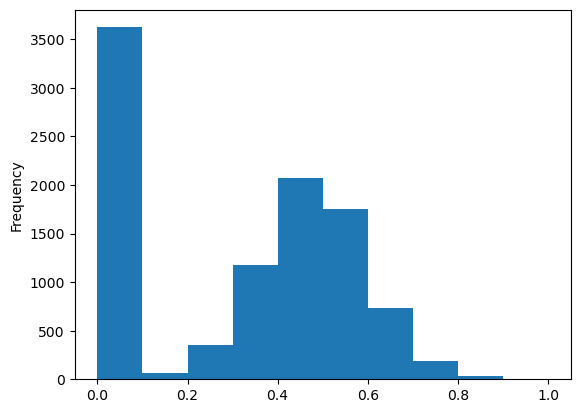

In [25]:
risk_score.plot(kind='hist')

In [49]:
df['Risk Score'] = risk_score
df['Exited'][df['Risk Score'] >= .7].value_counts()

Exited
0    156
1     63
Name: count, dtype: int64

## Customer Loyalty Score

In [28]:
loyalty_score = (df['Tenure'] * 2) + (df['IsActiveMember'] * 5) + (df['NumOfProducts'] * 3) + (df['Point Earned'] / 100)

In [30]:
loyalty_score.describe()

count    10000.000000
mean        23.256851
std          6.851595
min          5.250000
25%         18.160000
50%         23.235000
75%         28.350000
max         44.590000
dtype: float64

<Axes: ylabel='Count'>

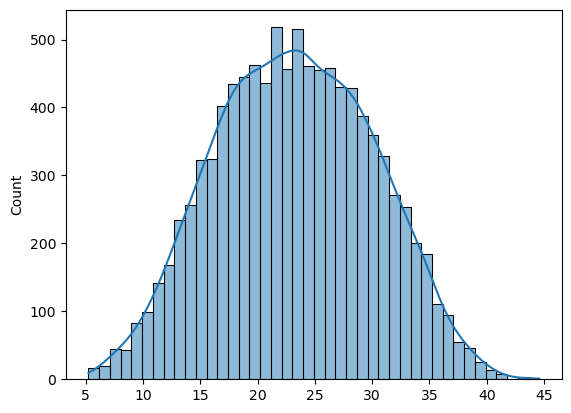

In [33]:
sns.histplot(loyalty_score, kde=True)